**Theory & Code Base Question**

**Q1.	GRU-Based	Named	Entity	Recognition	(NER)**

To	identify	entities	like	names,	locations,	and	organizations,	we	treat	the	text	as	a	sequence of	tokens.	A	Gated	Recurrent	Unit	(GRU)	processes	these	tokens	sequentially,	maintaining	a memory	of	context,	and	a	TimeDistributed	dense	layer	classifies	each	token.

In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding, GRU, Dense, TimeDistributed
from tensorflow.keras.models import Sequential

# configuration parameter
vocab_size = 5000
num_classes = 4   # O, B-PER, B-LOC, B-ORG
max_length = 20

# Structural implementation of the GRU NER Model
model = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=64,
        input_length=max_length
    ),

    GRU(
        units=64,
        return_sequences=True
    ),  # keeps token sequence intact

    TimeDistributed(
        Dense(num_classes, activation='softmax')
    )  # classifies each word individually
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Q2.	Interactive	English-to-Spanish	Dictionary**

This	program	uses	a	Python	dictionary	to	store	key-value	pairs	of	words	and	a	create	an	interactive	interface	for	adding	and	translating	words.

In [3]:
# Simple persistent translation session

dictionary = {
    "hello": "hola",
    "apple": "manzana",
    "computer": "computadora"
}

while True:

    print("--- English-to-Spanish Dictionary ---")

    action = input(
        "Choose an option: (1) Translate (2) Add Word (3) Exit: "
    ).strip()

    if action == "1":

        word = input("Enter English word: ").lower().strip()

        print(
            f"Translation: {dictionary.get(word, 'Word not found in dictionary.')}"
        )

    elif action == "2":

        eng = input("Enter new English word: ").lower().strip()

        esp = input("Enter Spanish translation: ").lower().strip()

        dictionary[eng] = esp

        print(f"Successfully added: {eng} -> {esp}")

    elif action == "3":

        print("Goodbye!")
        break

    else:

        print("Invalid choice. Please select 1, 2, or 3.")

--- English-to-Spanish Dictionary ---
Choose an option: (1) Translate (2) Add Word (3) Exit: 1
Enter English word: hello
Translation: hola
--- English-to-Spanish Dictionary ---
Choose an option: (1) Translate (2) Add Word (3) Exit: 2
Enter new English word: apple
Enter Spanish translation: 3
Successfully added: apple -> 3
--- English-to-Spanish Dictionary ---
Choose an option: (1) Translate (2) Add Word (3) Exit: Goodbye!
Invalid choice. Please select 1, 2, or 3.
--- English-to-Spanish Dictionary ---
Choose an option: (1) Translate (2) Add Word (3) Exit: 3
Goodbye!


**Q3.	Visualizing	Clustered	Groups	with	a	Scatter	Plot**

When	you	perform	clustering	(like	K-Means),	you	pass	the	calculated	cluster	assignments	into the	color	parameter	( c )	of	Matplotlib's	scatter	plot.	This	visually	separates	your	data	points into	distinct	colored	groups.

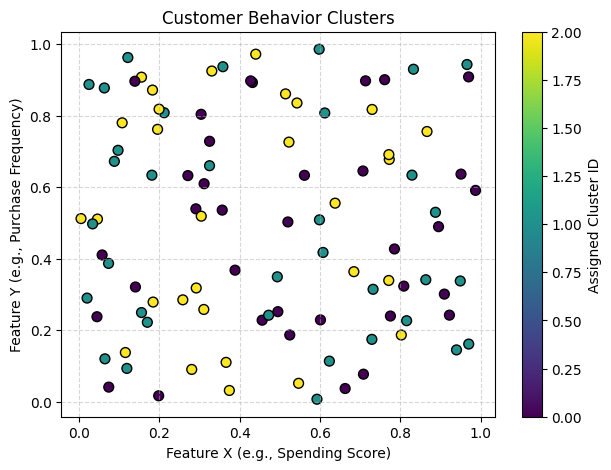

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Mock data representing 2D features and cluster assignments
np.random.seed(42)

x_coords = np.random.rand(100)
y_coords = np.random.rand(100)

# 3 distinct clusters (0, 1, or 2)
cluster_labels = np.random.randint(0, 3, size=100)

# Creating the scatter visualization
plt.figure(figsize=(7, 5))

scatter = plt.scatter(
    x_coords,
    y_coords,
    c=cluster_labels,
    cmap='viridis',
    s=50,
    edgecolors='k'
)

plt.title("Customer Behavior Clusters")

plt.xlabel("Feature X (e.g., Spending Score)")
plt.ylabel("Feature Y (e.g., Purchase Frequency)")

plt.colorbar(scatter, label="Assigned Cluster ID")

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

**Q4.	Strategic	Selection:	Azure	Vision	Service**

When	solving	a	vision	problem	in	Microsoft	Azure,	you	have	two	core	routes	depending	on	your business	requirements:

| Azure Service    | Azure AI Vision (Computer Vision)                                                                                                         | Azure AI Custom Vision                                                                                                                                                                                                                                                                             |
| ---------------- | ----------------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Primary Use Case | General image understanding                                                                                                               | Domain-specific identification                                                                                                                                                                                                                                                                     |
| Why Choose It?   | Best for broad tasks out-of-the-box: reading text from images (OCR), identifying generic objects (cars, people), or generating summaries. | The choice for custom problems: if you need to identify niche items (e.g., specific manufacturing defects on a circuit board, or proprietary retail products), Custom Vision allows you to upload a small subset of custom images and train a tailored classifier via an intuitive user interface. |


Decision	Rule:	For	general	visual	tasks,	use	Azure	AI	Vision.	For	unique	domainspecific	items,	use	Custom	Vision.

**Q5.	Linear	Regression	House	Price	Predictor**

This	model	maps	independent	structural	features	(Area	and	Location)	to	a	continuous	numerical output	(Price).	We	use	OneHotEncoder	to	transform	non-numerical	categorical	locations	into	clean binary	vectors.

In [5]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Data preparation
data = {
    'Area_SqFt': [1200, 1500, 850, 2100, 1350],

    'Location': [
        'Downtown',
        'Suburbs',
        'Downtown',
        'Suburbs',
        'Midtown'
    ],

    'Price': [350000, 290000, 240000, 420000, 310000]
}

df = pd.DataFrame(data)

X = df[['Area_SqFt', 'Location']]
y = df['Price']

# Preprocessing: Convert location categories to numerical data patterns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), ['Location'])
    ],
    remainder='passthrough'
)

X_processed = preprocessor.fit_transform(X)

# Model initialization & training
model = LinearRegression()

model.fit(X_processed, y)

# Sample prediction for a 1600 SqFt house in the Suburbs
sample_input = pd.DataFrame(
    [[1600, 'Suburbs']],
    columns=['Area_SqFt', 'Location']
)

sample_processed = preprocessor.transform(sample_input)

predicted_price = model.predict(sample_processed)

print(f"Predicted Price: ${predicted_price[0]:,.2f}")

Predicted Price: $306,709.84


**Q6.	Basic	next-Word	RNN	Implementation**

A	basic	Recurrent	Neural	Network	(RNN)	keeps	a	hidden	state	vector	that	gets	updated	at	each step	of	a	word	sequence,	capturing	simple	temporal	context	to	predict	the	immediate	next	token.

In [6]:
import tensorflow as tf

from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.models import Sequential

vocab_size = 1000
embedding_dim = 32

model = Sequential([

    # Input expects sequences of word indices
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    ),

    # Captures sequential text patterns
    SimpleRNN(
        units=64,
        return_sequences=False
    ),

    # Outputs probability across entire vocabulary
    Dense(
        units=vocab_size,
        activation='softmax'
    )
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Q7.	Automated	Diagnostics	with	Azure	Metrics	Advisor**

Azure	Metrics	Advisor	acts	as	an	automated	diagnostic	engine	for	time-series	infrastructure	orbusiness	key	performance	indicators	(KPIs).	Here	is	how	you	leverage	it:

 Ingestion:	You	connect	Metrics	Advisor	directly	to	your	data	feeds	(such	as	Azure	SQL, Application	Insights,	or	Cosmos	DB).

 Self-Learning Detection:	The	service	runs	background	machine	learning	models	on	your historical	data	trends	to	establish	a	dynamic	"normal"	baseline.	It	completely	bypasses	the need	to	manually	hardcode	warning	thresholds.

Root-Cause	Diagnosis:	When	an	anomaly	triggers	(e.g.,	a	sudden	drop	in	transactional checkouts),	Metrics	Advisor	groups	related	multi-dimensional	anomalies	together	into	an incident	tree,	pinpointing	exactly	which	region	or	demographic	caused	the	deviation.

**Q8.	Time-Series	Strategy	using	Azure	Anomaly	Detector**

To	discover	structural	anomalies	in	data	pipelines	without	building	custom	models,	you	can integrate	the	Azure	AI	Anomaly	Detector	API	through	a	streamlined	process:

1.	Ingestion	&	Sampling:	Structure	your	historical	logs	or	sensor	entries	into	a	clean	timeseries	format	containing	steady	interval	timestamps	and	numerical	entries.

2.	API	Integration	Mode	Selection:
      
     . Batch	Detection:	Run	the	entire	historical	series	through	the	service	to	find	major historical	shifts	or	global	anomalies.
       
    . Streaming	(Last-Point)	Detection:	Continually	send	the	latest	data	points	in	real	time to	immediately	determine	if	the	current	moment	is	a	severe	statistical	outlier.

3.	Sensitivity	Tuning:	Adjust	the	marginScale	parameter	via	the	API	configuration	to	fine-tune how	strict	or	forgiving	the	boundary	detection	should	be.

**Q9.	Securing	Azure	AI	Services	via	Virtual	Networks	(VNets)**

To	shield	enterprise	AI	workflows	from	public	web	vulnerabilities,	you	isolate	resources directly	within	an	Azure	Virtual	Network	(VNet):

In [ ]:
[	Internet	Traffic	]	â”€â”€â”€Xâ”€â”€â”€>	[	Blocked	Public	Endpoint	]
[	Your	Secure	VNet	]	â”€â”€â”€>	[	Private	Endpoint	(Private	IP)	]	â”€â”€â”€>	[	Azure	AI	Service	]

Private	Endpoints:	Create	a	Private	Endpoint	for	your	Azure	AI	resource.	This	registers	a private	IP	address	from	your	VNet	directly	to	the	service,	keeping	all	operational	traffic entirely	inside	Microsoft's	private	backbone	network.

Disable	Public	Access:	Toggle	the	network	configuration	settings	on	the	Azure	Portal	to strictly	deny	all	public	internet	access.

Firewalls	&	Network	Security	Groups	(NSGs):	Establish	inbound	and	outbound	firewall	rules on	your	subnets	to	guarantee	that	only	validated	application	servers	can	ping	your	models.

**Q10.	Scenario	Strategy:	Customer	Review	Analysis**

**Business	Scenario**

An	e-commerce	storefront	receives	thousands	of	written	product	reviews	daily	and	wants	to automatically	flag	furious	customers	and	tag	exact	product	pain	points	instantly.

**Chosen	Service:	Azure	AI	Language**

We	use	Azure	AI	Language	because	it	provides	robust,	pre-configured	natural	language capabilities	right	out	of	the	box.

**Why	This	Fits	Perfectly**

. Sentiment	Analysis:	Instantly	grades	text	strings	on	a	scale	from	positive	to	negative, allowing	the	customer	service	system	to	auto-route	negative	sentiment	directly	to	highpriority	resolution	agents.

. Named	Entity	Recognition	(NER)	&	Key	Phrase	Extraction:	Pulls	out	specific	names,	dates,	or product	attributes	mentioned	in	the	feedback	without	requiring	developers	to	write	custom text-parsing	rules.

**Q11.	Creative	Text	Passage	Generation	via	LSTM**

Long	Short-Term	Memory	networks	(LSTMs)	outperform	standard	RNNs	for	creative	writing	because their	specialized	gate	cells	retain	context	across	long	textual	distances.

In [8]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.models import Sequential

# Structural model layout
vocab_size = 2500

model = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=64
    ),

    LSTM(
        128,
        return_sequences=False
    ),

    Dense(
        vocab_size,
        activation='softmax'
    )
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy'
)

def generate_passage(
    seed_text,
    next_words_count,
    word_to_idx,
    idx_to_word,
    max_seq_len
):

    output = seed_text

    for _ in range(next_words_count):

        # Convert text tokens to indices and pad
        tokens = [
            word_to_idx.get(w, 0)
            for w in output.split()
        ]

        tokens = tf.keras.preprocessing.sequence.pad_sequences(
            [tokens],
            maxlen=max_seq_len
        )

        # Predict probability array for the next word
        predicted_probs = model.predict(tokens, verbose=0)

        next_idx = np.argmax(
            predicted_probs,
            axis=-1
        )[0]

        # Append back into sequence string
        next_word = idx_to_word.get(next_idx, "")

        if not next_word:
            break

        output += " " + next_word

    return output

**Q12.	Content	Moderation	Pipeline	Architecture**

To	screen	user-submitted	data	for	profanity,	explicit	imagery,	or	personal	data	leaks,	you construct	an	execution	pipeline	backed	by	Azure	AI	Content	Safety	(formerly	Content	Moderator):

In [ ]:
# Conceptual layout of an enterprise automated moderation process flow

import requests

def analyze_user_content(text_to_screen):

    # Azure AI Content Safety Endpoint configuration
    endpoint = "https://<your-resource>.cognitiveservices.azure.com/contentsafety/text:analyze?api-version=2023-10"

    headers = {
        "Ocp-Apim-Subscription-Key": "YOUR_AZURE_KEY",
        "Content-Type": "application/json"
    }

    payload = {
        "text": text_to_screen,

        "categories": [
            "Hate",
            "SelfHarm",
            "Sexual",
            "Violence"
        ]
    }

    response = requests.post(
        endpoint,
        json=payload,
        headers=headers
    ).json()

    # Process toxicity severity flags returned by Azure
    for block in response.get("categoriesAnalysis", []):

        # Threshold policy rule
        if block["severity"] > 2:

            return "REJECTED: Content violates platform guidelines."

    return "APPROVED"

**Q13.	Customer	Purchase	Behavior	Clustering	(K-Means)**

K-Means	identifies	natural	behavioral	groupings	by	minimizing	the	distance	between	individual customer	data	vectors	and	their	geometric	cluster	centers.

In [9]:
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Dataset tracking total transaction spend & monthly return frequencies
customer_data = {

    'Total_Spend': [1200, 50, 1500, 80, 1100, 95],

    'Return_Frequency': [1, 5, 0, 7, 2, 6]
}

df = pd.DataFrame(customer_data)

# Scaling features is essential for distance-based calculations
scaler = StandardScaler()

scaled_features = scaler.fit_transform(df)

# Initialize and fit K-Means
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init='auto'
)

df['Cluster_ID'] = kmeans.fit_predict(scaled_features)

print("Segmented Customer Output Data:")

print(df)

Segmented Customer Output Data:
   Total_Spend  Return_Frequency  Cluster_ID
0         1200                 1           0
1           50                 5           1
2         1500                 0           0
3           80                 7           1
4         1100                 2           0
5           95                 6           1


**Q14.	Sequence-to-Sequence	GRU	Translator	Design**

Machine	translation	leverages	an	Encoder-Decoder	architecture.	The	Encoder	condenses	the	source English	sequence	into	a	dense	vector,	which	the	Decoder	then	unpacks	into	target	French	words.

In [10]:
import tensorflow as tf

from tensorflow.keras.layers import Embedding, GRU, Dense
from tensorflow.keras import Model, Input

vocab_size_en = 3000
vocab_size_fr = 3500

latent_dim = 128

# 1. Encoder Framework
encoder_inputs = Input(shape=(None,))

enc_emb = Embedding(
    vocab_size_en,
    latent_dim
)(encoder_inputs)

_, encoder_state = GRU(
    latent_dim,
    return_state=True
)(enc_emb)

# 2. Decoder Framework
decoder_inputs = Input(shape=(None,))

dec_emb_layer = Embedding(
    vocab_size_fr,
    latent_dim
)

dec_emb = dec_emb_layer(decoder_inputs)

decoder_gru = GRU(
    latent_dim,
    return_sequences=True,
    return_state=True
)

# Using context vector as seed
dec_outputs, _ = decoder_gru(
    dec_emb,
    initial_state=encoder_state
)

decoder_dense = Dense(
    vocab_size_fr,
    activation='softmax'
)

decoder_outputs = decoder_dense(dec_outputs)

# Definitive Seq2Seq Translation Model
translator_model = Model(
    [encoder_inputs, decoder_inputs],
    decoder_outputs
)

translator_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy'
)

translator_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, None, 128) │    384,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, None, 128) │    448,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ [(None, 128),     │     99,072 │ embedding_4[0][0] │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_2 (GRU)         │ [(None, None,     │     99,072 │ embedding_5[0][0… │
│                     │ 128), (None,      │            │ gru_1[0][1]       │
│                     │ 128)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, None,      │    451,500 │ gru_2[0][0]       │
│                     │ 3500)             │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,481,644 (5.65 MB)

 Trainable params: 1,481,644 (5.65 MB)

 Non-trainable params: 0 (0.00 B)

**Q15.	Visualizing	Exam	Score	Distributions	via	Histograms**

Histograms	segment	continuous	data	metrics	(like	raw	score	tallies)	into	contiguous	bins, showing	the	count	density	of	observations	across	different	value	ranges.

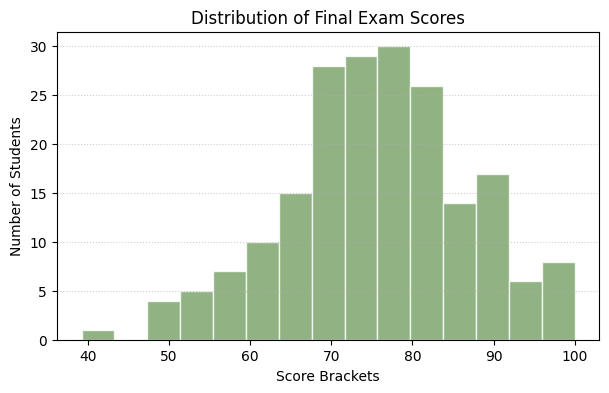

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Generate random normal distribution representing student test scores
np.random.seed(10)

exam_scores = np.random.normal(
    loc=75,
    scale=12,
    size=200
)

# Keep bounds realistic
exam_scores = np.clip(exam_scores, 0, 100)

plt.figure(figsize=(7, 4))

plt.hist(
    exam_scores,
    bins=15,
    color='#76a065',
    edgecolor='white',
    alpha=0.8
)

plt.title("Distribution of Final Exam Scores")

plt.xlabel("Score Brackets")
plt.ylabel("Number of Students")

plt.grid(
    axis='y',
    linestyle=':',
    alpha=0.6
)

plt.show()

**Q16.	Statistical	Correlation	Analysis**

The	Pearson	correlation	coefficient	measures	the	linear	strength	between	two	attributes.	The resulting	coefficient	value	sits	within	a	mathematical	range	from	-1	to	1:

Near	1:	Strong	positive	linear	pattern	(as	X	climbs,	Y	climbs).

Near	-1:	Strong	negative	inverse	pattern	(as	X	climbs,	Y	drops).

Near	0:	No	obvious	linear	relationship.

In [12]:
import pandas as pd

study_analytics = {

    'Hours_Studied': [2, 9, 5, 7, 1, 8],

    'Test_Score': [51, 94, 73, 88, 45, 91]
}

df = pd.DataFrame(study_analytics)

# Calculate linear Pearson matrix
correlation_matrix = df.corr(method='pearson')

coefficient = correlation_matrix.loc[
    'Hours_Studied',
    'Test_Score'
]

print(f"Calculated Correlation Coefficient: {coefficient:.4f}")

Calculated Correlation Coefficient: 0.9938


**Q17.	Training	Sequence	Models	for	Sentence	Completion**

To	train	an	LSTM	model	to	complete	input	sentences,	we	use	a	rolling	window	approach.	The	model learns	to	predict	a	target	token	by	analyzing	a	sliding	history	of	preceding	words.

Input	Tokens:		[	"The",	"data",	"scientist"	]		â”€â”€>		Target	Prediction	Token:	[	"engineered"	]

In [14]:
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

sentences = [
    "Deep learning models require clean data",
    "Neural networks learn patterns from text"
]

# Vectorizing text lines into token index chains
tokenizer = Tokenizer()

tokenizer.fit_on_texts(sentences)

sequences = tokenizer.texts_to_sequences(sentences)

X, y = [], []

for seq in sequences:

    for i in range(1, len(seq)):

        # Context slice
        X.append(seq[:i])

        # Single next token target
        y.append(seq[i])

max_len = max(len(x) for x in X)

X_padded = pad_sequences(
    X,
    maxlen=max_len,
    padding='pre'
)

y_categorical = tf.keras.utils.to_categorical(
    y,
    num_classes=len(tokenizer.word_index) + 1
)

# Training X_padded against y_categorical
# into standard LSTM completes the pipeline.

**Q18.	Naive	Bayes	Spam	Classification**

This	architecture	converts	raw	text	strings	into	a	bag-of-words	matrix	using	CountVectorizer .	It then	applies	a	Multinomial	Naive	Bayes	classifier	to	calculate	the	probability	that	an	email	is spam	based	on	word	frequencies.

In [15]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

# Training dataset
emails = [
    "Urgent response required! Click here to claim your cash prize now!",
    "Hey, are we still meeting up for coffee tomorrow afternoon?",
    "Free stock alerts. Double your wealth in three business days.",
    "Please find attached the project spreadsheet for your review."
]

labels = [
    "Spam",
    "Ham (Normal)",
    "Spam",
    "Ham (Normal)"
]

# Vectorize text blocks into word count vectors
vectorizer = CountVectorizer()

X_counts = vectorizer.fit_transform(emails)

# Train the classifier
classifier = MultinomialNB()

classifier.fit(X_counts, labels)

# Run an evaluation on a new incoming email string
incoming_email = ["Get rich quick by clicking this link!"]

incoming_counts = vectorizer.transform(incoming_email)

prediction = classifier.predict(incoming_counts)

print(f"Classification Result: {prediction[0]}")

Classification Result: Ham (Normal)
